In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

import pandas as pd
import numpy as np
import pickle, json, time
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
import os
base = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz'
print(os.listdir(base + '/images'))
print(os.listdir(base + '/images/images'))

['images']
['bathroom', 'pool', 'bedroom', 'kitchen', 'home-office', 'living-room']


In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PREP = Path('/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/for data kaggle/for data kaggle/stage3_preprocessing/preprocessing_outputs')



with open(PREP / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)           # load the vocab dictionary saved in Stage 3

word2idx   = vocab['word2idx']       # word → integer index
idx2word   = vocab['idx2word']       # integer index → word
VOCAB_SIZE = vocab['vocab_size']     # 4207
PAD_IDX    = vocab['pad_idx']        # 0
START_IDX  = vocab['start_idx']      # 1
END_IDX    = vocab['end_idx']        # 2

with open(PREP / 'preprocessing_config.json') as f:
    cfg = json.load(f)

train_df = pd.read_csv(PREP / 'split_train.csv')
val_df   = pd.read_csv(PREP / 'split_val.csv')
test_df  = pd.read_csv(PREP / 'split_test.csv')

# tokens were saved as strings in CSV → eval() converts them back to Python lists
train_df['tokens'] = train_df['tokens'].apply(eval)
val_df['tokens']   = val_df['tokens'].apply(eval)
test_df['tokens']  = test_df['tokens'].apply(eval)

print('vocab size :', VOCAB_SIZE)
print('train      :', len(train_df))
print('val        :', len(val_df))
print('test       :', len(test_df))


vocab size : 4207
train      : 10984
val        : 1373
test       : 1374


In [4]:


EMBED_DIM   = 256    # size of word embeddings AND image feature vector (must match so LSTM accepts both)
HIDDEN_DIM  = 512    # LSTM hidden state size
NUM_LAYERS  = 1      # number of LSTM layers stacked

BATCH_SIZE  = 32     # images processed per gradient update
LR          = 3e-4   # Adam learning rate
NUM_EPOCHS  = 50     # max epochs — early stopping will kick in earlier
PATIENCE    = 5      # stop if val_loss doesn't improve for 5 consecutive epochs

IMAGES_BASE = Path('/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/images/images')

In [5]:
class HouzzDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)         # how many items in the dataset

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = '/'.join(row['local_path'].split('/')[1:])  # يشيل أول "images/"
        image = Image.open(IMAGES_BASE / img_name).convert('RGB')        
        if self.transform:
            image = self.transform(image)       # resize + normalize the image
        caption = torch.tensor(row['tokens'], dtype=torch.long)
        return image, caption                   # returns one (image, caption) pair


In [6]:
transform = transforms.Compose([
    transforms.Resize(tuple(cfg['IMG_SIZE'])),                         # → 224×224
    transforms.ToTensor(),                                             # pixel [0,255] → tensor [0,1]
    transforms.Normalize(mean=cfg['IMG_MEAN'], std=cfg['IMG_STD']),   # ImageNet stats
])

train_ds = HouzzDataset(train_df, transform)
val_ds   = HouzzDataset(val_df,   transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)  # shuffle=True → randomize order each epoch
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('train batches :', len(train_loader))
print('val batches   :', len(val_loader))


train batches : 344
val batches   : 43


In [7]:
# Encoder  →  ResNet50 pretrained on ImageNet , ALL layers FROZEN
# input  : image  (B , 3 , 224 , 224)
# output : feature vector  (B , embed_dim)
class Encoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for p in resnet.parameters():
            p.requires_grad = False          # freeze ALL layers — nothing trains inside ResNet

        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # remove final FC → output (B,2048,1,1)
        self.fc = nn.Linear(resnet.fc.in_features, embed_dim)          # 2048 → 256 , this layer DOES train

    def forward(self, images):
        with torch.no_grad():               # no gradient through backbone → saves GPU memory
            x = self.backbone(images)
        x = x.flatten(1)                   # (B,2048,1,1) → (B,2048)
        return self.fc(x)                  # (B,2048) → (B,256)


In [8]:
# Decoder  →  Embedding + LSTM + Linear
# image vector goes in as the LSTM's first input at t=0 , then captions[:-1] follow
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)  # token ID → 256-dim vector
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)  # 256 in , 512 hidden
        self.fc    = nn.Linear(hidden_dim, vocab_size)  # 512 → 4207 (score for every word in vocab)

    def forward(self, features, captions):
        embeddings = self.embed(captions[:, :-1])   # embed all tokens except the last
        features   = features.unsqueeze(1)           # (B,256) → (B,1,256) — add time dimension
        inputs     = torch.cat([features, embeddings], dim=1)  # image at t=0 , then words t=1,2,...
        out, _ = self.lstm(inputs)                   # run full LSTM sequence at once
        return self.fc(out)                          # project to vocab scores at every timestep


In [9]:
class CaptionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.encoder = Encoder(embed_dim)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim, num_layers)

    def forward(self, images, captions):
        features = self.encoder(images)              # image → 256-dim vector
        return self.decoder(features, captions)      # vector + captions → word scores

    def generate(self, image, max_len=40):
        # greedy decoding — no teacher forcing , pick argmax at each step
        self.eval()
        with torch.no_grad():
            features = self.encoder(image.unsqueeze(0))
            inputs   = features.unsqueeze(1)     # first LSTM input = image feature
            hidden   = None                      # LSTM starts with no memory
            words    = []

            for _ in range(max_len):
                out, hidden = self.decoder.lstm(inputs, hidden)   # one LSTM step
                logits = self.decoder.fc(out[:, -1, :])           # scores for next word
                pred   = logits.argmax(1).item()                  # pick highest-scoring word

                if pred == END_IDX: break                         # stop at <END>
                if pred not in (PAD_IDX, START_IDX):
                    words.append(idx2word[pred])                  # add word to output

                next_token = torch.tensor([[pred]], device=image.device)
                inputs = self.decoder.embed(next_token)           # embed predicted word → next input

        return ' '.join(words)


In [10]:
model = CaptionModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'trainable params : {trainable:,}')   # → ~3.5M  (only decoder + bridge fc)
print(f'total params     : {total:,}')        # → ~28M   (ResNet frozen but still counted)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # ignore PAD tokens in loss
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


trainable params : 5,336,687
total params     : 28,844,719


In [11]:
# smoke test  →  feed dummy data , verify shapes are correct before real training
B = 2
dummy_imgs = torch.randn(B, 3, 224, 224).to(DEVICE)
dummy_caps = torch.randint(0, VOCAB_SIZE, (B, cfg['MAX_CAPTION_LEN'])).to(DEVICE)

logits = model(dummy_imgs, dummy_caps)
print('input image shape  :', dummy_imgs.shape)
print('input caption shape:', dummy_caps.shape)
print('output logits shape:', logits.shape)    # → (2, 40, 4207)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), dummy_caps.reshape(-1))  # flatten batch+time for CrossEntropy
print('test loss          :', loss.item())


input image shape  : torch.Size([2, 3, 224, 224])
input caption shape: torch.Size([2, 40])
output logits shape: torch.Size([2, 40, 4207])
test loss          : 8.347192764282227


In [12]:
print(train_df['local_path'].iloc[0])
print(train_df['local_path'].iloc[1])
print(train_df['local_path'].iloc[2])

images/home-office/home-office_00740.jpg
images/pool/poolroom_02998.jpg
images/pool/poolroom_02439.jpg


In [13]:
SAVE = Path('model_outputs')
SAVE.mkdir(exist_ok=True)

history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # ── TRAIN ──
    model.train()                                    # enable dropout / batchnorm updates
    total_train = 0
    for images, captions in train_loader:
        images, captions = images.to(DEVICE), captions.to(DEVICE)
        logits = model(images, captions)             # forward pass
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), captions.reshape(-1))
        optimizer.zero_grad()                        # clear old gradients
        loss.backward()                              # compute new gradients
        optimizer.step()                             # update weights
        total_train += loss.item()

    # ── VALIDATE ──
    model.eval()
    total_val = 0
    with torch.no_grad():                            # no gradient tracking needed
        for images, captions in val_loader:
            images, captions = images.to(DEVICE), captions.to(DEVICE)
            logits = model(images, captions)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), captions.reshape(-1))
            total_val += loss.item()

    train_loss = total_train / len(train_loader)
    val_loss   = total_val   / len(val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # ── EARLY STOPPING ──
    flag = ''
    if val_loss < best_val:
        best_val = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE / 'model1_frozen_best.pt')  # save best checkpoint
        flag = ' ← saved'
    else:
        patience_counter += 1

    print(f'epoch {epoch+1:>2}/{NUM_EPOCHS}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'({time.time()-t0:.0f}s){flag}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹  early stopping — val loss did not improve for {PATIENCE} epochs')
        break

print(f'\nbest val loss: {best_val:.4f}')

with open(SAVE / 'model1_frozen_history.json', 'w') as f:
    json.dump(history, f, indent=2)


epoch  1/50  train=4.2802  val=3.2690  (63s) ← saved
epoch  2/50  train=3.1841  val=2.9390  (52s) ← saved
epoch  3/50  train=2.9253  val=2.7940  (57s) ← saved
epoch  4/50  train=2.7592  val=2.6895  (56s) ← saved
epoch  5/50  train=2.6313  val=2.6235  (56s) ← saved
epoch  6/50  train=2.5253  val=2.5791  (56s) ← saved
epoch  7/50  train=2.4286  val=2.5447  (56s) ← saved
epoch  8/50  train=2.3414  val=2.5223  (56s) ← saved
epoch  9/50  train=2.2639  val=2.5017  (57s) ← saved
epoch 10/50  train=2.1840  val=2.4873  (56s) ← saved
epoch 11/50  train=2.1073  val=2.4813  (56s) ← saved
epoch 12/50  train=2.0353  val=2.4784  (57s) ← saved
epoch 13/50  train=1.9638  val=2.4768  (56s) ← saved
epoch 14/50  train=1.8944  val=2.4814  (56s)
epoch 15/50  train=1.8245  val=2.4867  (56s)
epoch 16/50  train=1.7589  val=2.4949  (55s)
epoch 17/50  train=1.6930  val=2.5031  (56s)
epoch 18/50  train=1.6299  val=2.5168  (56s)

⏹  early stopping — val loss did not improve for 5 epochs

best val loss: 2.4768


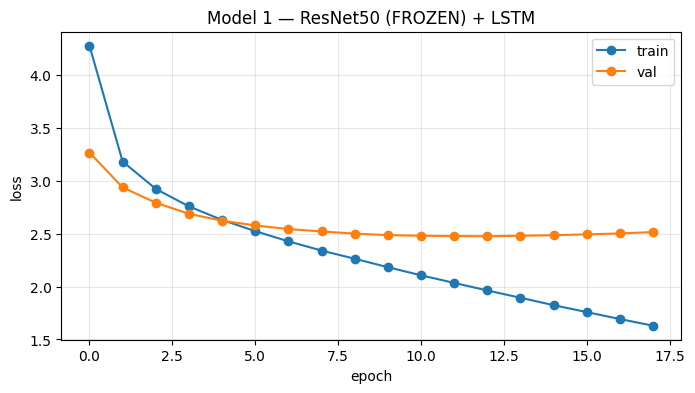

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train', marker='o')
plt.plot(history['val_loss'],   label='val',   marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Model 1 — ResNet50 (FROZEN) + LSTM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [15]:
model.load_state_dict(torch.load(SAVE / 'model1_frozen_best.pt', map_location=DEVICE))
model.eval()

samples = val_df.sample(5, random_state=0).reset_index(drop=True)

for i, row in samples.iterrows():
    img_name = '/'.join(row['local_path'].split('/')[1:])  # شيل أول "images/"
    img = Image.open(IMAGES_BASE / img_name).convert('RGB')
    img_t = transform(img).to(DEVICE)
    generated = model.generate(img_t, max_len=cfg['MAX_CAPTION_LEN'])

    print(f'--- sample {i+1} ({row["room_type"]}) ---')
    print(f'  image    : {row["local_path"]}')
    print(f'  true     : {row["caption"][:130]}')
    print(f'  generated: {generated}')
    print()


--- sample 1 (home-office) ---
  image    : images/home-office/home-office_00325.jpg
  true     : elegant freestanding desk light wood floor and brown floor study room with beige walls
  generated: medium tone wood floor and brown floor living room with white walls a standard fireplace and a stone fireplace

--- sample 2 (bedroom) ---
  image    : images/bedroom/bedroom_02946.jpg
  true     : bob greenspan master dark wood floor bedroom with gray walls
  generated: guest medium tone wood floor and brown floor bedroom with white walls and no fireplace

--- sample 3 (bathroom) ---
  image    : images/bathroom/bathroom_01837.jpg
  true     : a serene primary bathroom wrapped in bookmatched marble creates a spa like retreat in this reimagined lincoln park duplex the free
  generated: master white tile and porcelain tile porcelain tile and gray floor bathroom with flat panel cabinets medium tone wood cabinets a one piece toilet white walls an undermount sink quartz countertops a hinged show

In [16]:
!pip install nltk rouge-score pycocoevalcap -q

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 18.5 MB/s eta 0:00:00


True

In [17]:
from tqdm.auto import tqdm

predictions = []
references  = []

for idx in tqdm(range(len(test_df)), desc='generating'):
    row = test_df.iloc[idx]
    img_name = '/'.join(row['local_path'].split('/')[1:])
    img = Image.open(IMAGES_BASE / img_name).convert('RGB')
    img_t = transform(img).to(DEVICE)
    gen = model.generate(img_t, max_len=cfg['MAX_CAPTION_LEN'])
    predictions.append(gen)
    references.append(row['caption'])

print(f'\ngenerated {len(predictions)} captions')


generating:   0%|          | 0/1374 [00:00<?, ?it/s]


generated 1374 captions


In [18]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

hyps = [p.split() for p in predictions]   # list of token lists
refs = [[r.split()] for r in references]  # list of [reference token list] — BLEU expects nested list

smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(refs, hyps, weights=(1.0, 0, 0, 0),    smoothing_function=smooth)  # unigram precision
bleu4 = corpus_bleu(refs, hyps, weights=(0.25,)*4,          smoothing_function=smooth)  # 4-gram precision

meteor = sum(meteor_score(r, h) for r, h in zip(refs, hyps)) / len(hyps)  # synonym-aware overlap

rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = sum(rouge.score(r, h)['rougeL'].fmeasure for h, r in zip(predictions, references)) / len(predictions)

try:
    from pycocoevalcap.cider.cider import Cider
    gts = {i: [references[i]]  for i in range(len(references))}
    res = {i: [predictions[i]] for i in range(len(predictions))}
    cider, _ = Cider().compute_score(gts, res)   # TF-IDF weighted — most reliable for captioning
except Exception as e:
    print(f'CIDEr failed: {e}')
    cider = None

print(f'BLEU-1  : {bleu1:.4f}')
print(f'BLEU-4  : {bleu4:.4f}')
print(f'METEOR  : {meteor:.4f}')
print(f'ROUGE-L : {rouge_l:.4f}')
print(f'CIDEr   : {cider:.4f}' if cider is not None else 'CIDEr   : n/a')


BLEU-1  : 0.3714
BLEU-4  : 0.1704
METEOR  : 0.3710
ROUGE-L : 0.3712
CIDEr   : 0.8904


In [19]:
metrics = {
    'model'         : 'Model 1 — ResNet50 (FROZEN) + LSTM',
    'best_val_loss' : round(min(history['val_loss']), 4),
    'test_samples'  : len(predictions),
    'BLEU-1'        : round(bleu1,   4),
    'BLEU-4'        : round(bleu4,   4),
    'METEOR'        : round(meteor,  4),
    'ROUGE-L'       : round(rouge_l, 4),
    'CIDEr'         : round(cider,   4) if cider is not None else None,
}

with open(SAVE / 'model1_frozen_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# also save predictions side-by-side with ground-truth for report / error analysis
results = test_df[['local_path', 'room_type', 'caption']].copy().rename(columns={'caption': 'true_caption'})
results['generated'] = predictions
results.to_csv(SAVE / 'model1_frozen_predictions.csv', index=False)

print(json.dumps(metrics, indent=2))


{
  "model": "Model 1 \u2014 ResNet50 (FROZEN) + LSTM",
  "best_val_loss": 2.4768,
  "test_samples": 1374,
  "BLEU-1": 0.3714,
  "BLEU-4": 0.1704,
  "METEOR": 0.371,
  "ROUGE-L": 0.3712,
  "CIDEr": 0.8904
}


In [20]:
correct = 0

room_keywords = {
    'bathroom':    ['bathroom', 'bath', 'shower', 'toilet', 'vanity'],
    'bedroom':     ['bedroom', 'bed', 'master'],
    'home-office': ['office', 'desk', 'study'],
    'kitchen':     ['kitchen', 'pantry'],
    'living-room': ['living', 'lounge'],
    'pool':        ['pool', 'hot tub', 'spa'],
}

for idx in range(len(test_df)):
    room      = test_df.iloc[idx]['room_type']
    generated = predictions[idx].lower()
    if any(kw in generated for kw in room_keywords[room]):
        correct += 1

print(f'Overall Accuracy : {correct / len(test_df) * 100:.1f}%')

Overall Accuracy : 81.8%
